# Разведочный анализ данных

## Предварительная настройка

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
palette = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ab17d", "#b5179e"]

In [52]:
rename_dict = {
    "new_id": "store_id",
    "Год": "year",
    "Месяц": "month",
    "Среднее количество промо товаров в чеке": "avg_promo_items",
    "Среднее количество товаров в чеке": "avg_items",
    "Среднее количество отмен": "avg_cancels",
    "Рабочие часы в день": "working_hours",
    "Дата открытия, категориальный": "opening_date_cat",
    "Торговая площадь, категориальный": "store_area_cat",
    "Населенный пункт": "city",
    "Регион": "region",
    "Численность населения": "population",
    "Количество домохозяйств": "households",
    "Трафик пеший, в час": "foot_traffic",
    "Трафик авто, в час": "car_traffic",
    "Маркетплейсы, доставки, постаматы (100 м)": "marketplaces_100m",
    "Медицинские уч. и аптеки (300 м)": "pharmacy_300m",
    "Школы (300 м)": "schools_300m",
    "Остановки (300 м)": "stops_300m",
    "Продуктовые магазины (500 м)": "grocery_500m",
    "Пятерочки (500 м)": "pyaterochka_500m",
    "Количество касс": "cash_registers",
    "Флаг алкогольной лицензии": "alcohol_license",
    "РТО": "rto",
}

## Постановка задачи

Задача состоит в прогнозировании РТО на февраль для сети магазинов пятерочка.

Для оценки качества предсказаний будет использоваться функция следующего вида:

$$
\text{MAPE} = 100*\frac{1}{n}*\sum_{i=1}^n
\lvert
\frac{y_{\text{pred}_i} - y_{\text{true}_i}}{y_{\text{true}_i}}
\rvert
$$

$$
\text{score} = 100 - \text{min}(\text{MAPE}, 100)
$$

In [54]:
def get_score(y_true: np.ndarray, predictions: np.ndarray) -> tuple:
    eps_cons = 1e-8
    mape = 100 * np.mean(np.abs((predictions - y_true) / np.maximum(y_true, eps_cons)))
    score = 100 * ((100 - min(mape, 100)) / 100) ** 2
    return mape, score

Из описания датасета:

| Название колонки | Тип данных | Описание |
| :--- | :--- | :--- |
| **store_id** | `int64` | Уникальный идентификатор магазина |
| **year** / **month** | `int64` | Год и месяц наблюдения |
| **rto** | `float64` | **Целевая переменная:** Розничный товарооборот за месяц |
| **avg_items** / **avg_promo_items**| `float64` | Среднее кол-во товаров / промо-товаров в одном чеке |
| **avg_cancels** | `float64` | Среднее количество отмен чеков |
| **working_hours** | `float64` | Количество рабочих часов магазина в день |
| **opening_date_cat** | `object` | Категория даты открытия магазина |
| **store_area_cat** | `object` | Категория торговой площади |
| **city** / **region** | `object` | Населенный пункт и регион РФ |
| **population** / **households** | `int64` | Численность населения и кол-во домохозяйств вокруг |
| **foot_traffic** / **car_traffic** | `int64` | Пешеходный и автомобильный трафик в час |
| **marketplaces_100m** | `int64` | Кол-во маркетплейсов, доставок и постаматов в радиусе 100м |
| **pharmacy_300m** / **schools_300m** | `int64` | Кол-во аптек/мед.учреждений и школ в радиусе 300м |
| **stops_300m** | `int64` | Количество остановок общественного транспорта в радиусе 300м |
| **grocery_500m** / **pyaterochka_500m**| `int64` | Кол-во продуктовых конкурентов и других Пятёрочек в радиусе 500м |
| **cash_registers** | `int64` | Количество касс в магазине |
| **alcohol_license** | `int64` | Флаг наличия алкогольной лицензии (0 или 1) |

## EDA

In [55]:
df = pd.read_csv("train_2.csv")
df = df.rename(columns=rename_dict)
df.sample(5)

,store_id,year,month,avg_promo_items,avg_items,avg_cancels,working_hours,opening_date_cat,store_area_cat,city,...,car_traffic,marketplaces_100m,pharmacy_300m,schools_300m,stops_300m,grocery_500m,pyaterochka_500m,cash_registers,alcohol_license,rto
321408,14390,2024,11,0.87,4.55,224.0,12.0,Новый,Маленький,Красноярск г,...,366,2,0,0,4,5,3,6,1,6.693571e+07
412227,18458,2024,11,0.61,4.35,640.0,16.0,Новый,Большой,Волгоград г,...,393,4,2,0,2,5,1,11,1,1.119804e+08
205808,9254,2024,9,1.38,7.45,71.0,16.0,Средний по возрасту,Средний,Волоколамск г,...,266,0,0,0,0,0,0,5,1,8.542024e+07
291857,13104,2023,3,1.36,5.48,546.0,17.0,Средний по возрасту,Большой,Москва г,...,461,7,3,1,1,7,2,9,1,1.189250e+08
199605,8976,2023,2,1.46,8.08,93.0,14.0,Новый,Средний,Савельево д,...,0,0,0,1,0,0,0,9,1,6.215565e+07


Изучим основные характеристики датасета:

In [56]:
print(f"Размер датасета: {df.shape[0]}")
print(f"Количество колонок: {df.shape[1]}")
print(f"Наличие дубликатов: {df.duplicated().any()}\n")
print(f"Наличие пропусков:\n{df.isna().sum().sort_values(ascending=False)}")

Размер датасета: 485082
Количество колонок: 24
Наличие дубликатов: False

Наличие пропусков:
store_id             0
year                 0
alcohol_license      0
cash_registers       0
pyaterochka_500m     0
grocery_500m         0
stops_300m           0
schools_300m         0
pharmacy_300m        0
marketplaces_100m    0
car_traffic          0
foot_traffic         0
households           0
population           0
region               0
city                 0
store_area_cat       0
opening_date_cat     0
working_hours        0
avg_cancels          0
avg_items            0
avg_promo_items      0
month                0
rto                  0
dtype: int64


In [57]:
def get_stats(X):
    uniques = X.nunique()
    return pd.DataFrame(
        {
            "Количество уникальных": uniques,
            "Доля": np.round(uniques / X.shape[0] * 100, 2),
            "Тип данных": X.dtypes,
        }
    ).sort_values(by="Доля", ascending=False)

In [58]:
get_stats(df).head(10)

,Количество уникальных,Доля,Тип данных
rto,485070,100.00,float64
store_id,18657,3.85,int64
population,17205,3.55,int64
households,7912,1.63,int64
city,3270,0.67,object
avg_cancels,2792,0.58,float64
car_traffic,1078,0.22,int64
avg_items,998,0.21,float64
foot_traffic,542,0.11,int64
avg_promo_items,279,0.06,float64


### Анализ целевой переменной

In [59]:
df_rto = df["rto"]
df_rto.describe()

count    4.850820e+05
mean     8.853480e+07
std      4.824900e+07
min      1.179116e+06
25%      5.627279e+07
50%      7.521094e+07
75%      1.057677e+08
max      6.557204e+08
Name: rto, dtype: float64

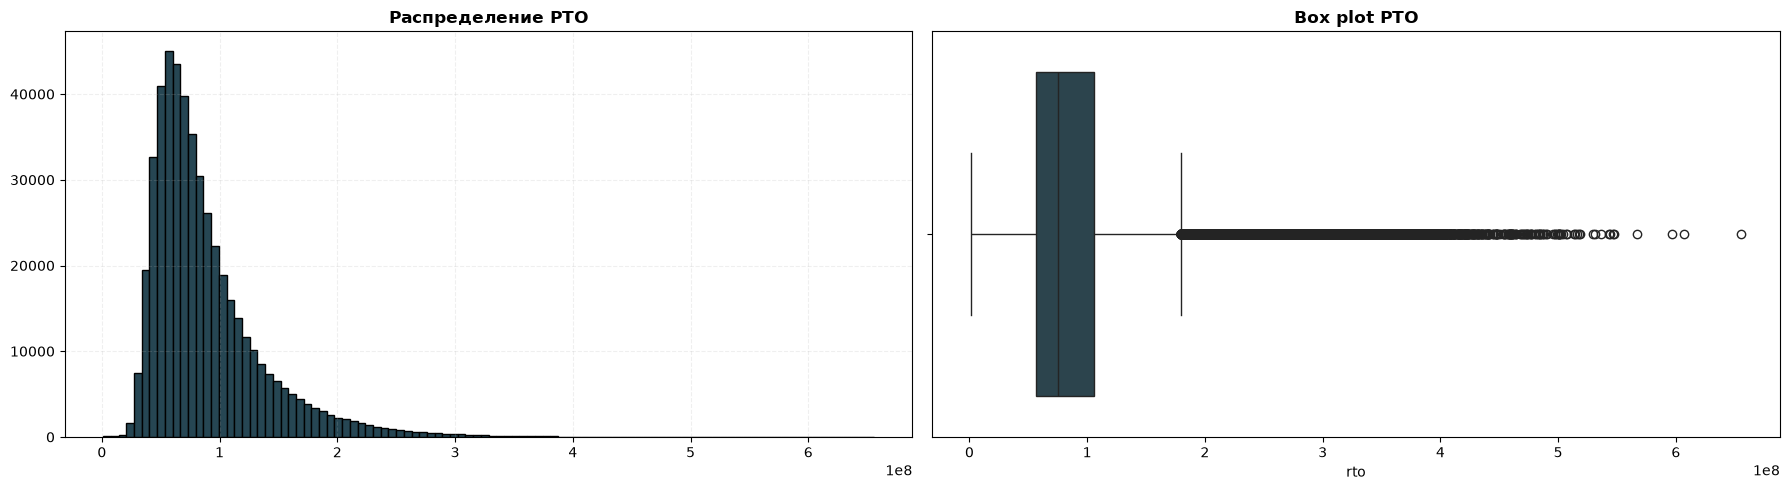

In [60]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

axes[0].hist(
    df_rto,
    bins=100,
    color=palette[0],
    edgecolor="black",
)
axes[0].set_title("Распределение РТО", weight="bold")
axes[0].grid(linestyle="--", alpha=0.2)

sns.boxplot(x=df_rto, color=palette[0], ax=axes[1])
axes[1].set_title("Box plot РТО", weight="bold")

plt.tight_layout()

### Анализ аномально высокой выручки

Изучим топ-1% магазинов по обороту, чтобы понять, что объединяет самые прибыльные точки.

In [61]:
rto_threshold_99 = df["rto"].quantile(0.99)
df_high_rto = df[df["rto"] > rto_threshold_99]

print(f"Порог 99-го квантиля: {np.round(rto_threshold_99, 2)} руб")
print(f"Количество записей в топ-1%: {len(df_high_rto)}")
df_high_rto.sample(3)

Порог 99-го квантиля: 265394753.81 руб
Количество записей в топ-1%: 4851


,store_id,year,month,avg_promo_items,avg_items,avg_cancels,working_hours,opening_date_cat,store_area_cat,city,...,car_traffic,marketplaces_100m,pharmacy_300m,schools_300m,stops_300m,grocery_500m,pyaterochka_500m,cash_registers,alcohol_license,rto
352135,15793,2023,8,1.75,8.69,1395.0,12.0,Средний по возрасту,Очень большой,Шаховская пгт.,...,558,3,2,0,5,4,1,16,1,4.176590e+08
436145,19534,2023,10,1.43,7.17,1169.0,13.0,Средний по возрасту,Очень большой,Москва г,...,326,6,4,0,8,7,1,12,1,3.851895e+08
476944,21378,2025,1,1.05,13.63,76.0,12.0,Средний по возрасту,Средний,Рыльск г,...,958,3,0,0,0,0,0,9,0,3.175665e+08


### Анализ зависимостей для топ-1% магазинов

Оценим, как ключевые количественные показатели влияют на РТО в сегменте сверхприбыльных точек.

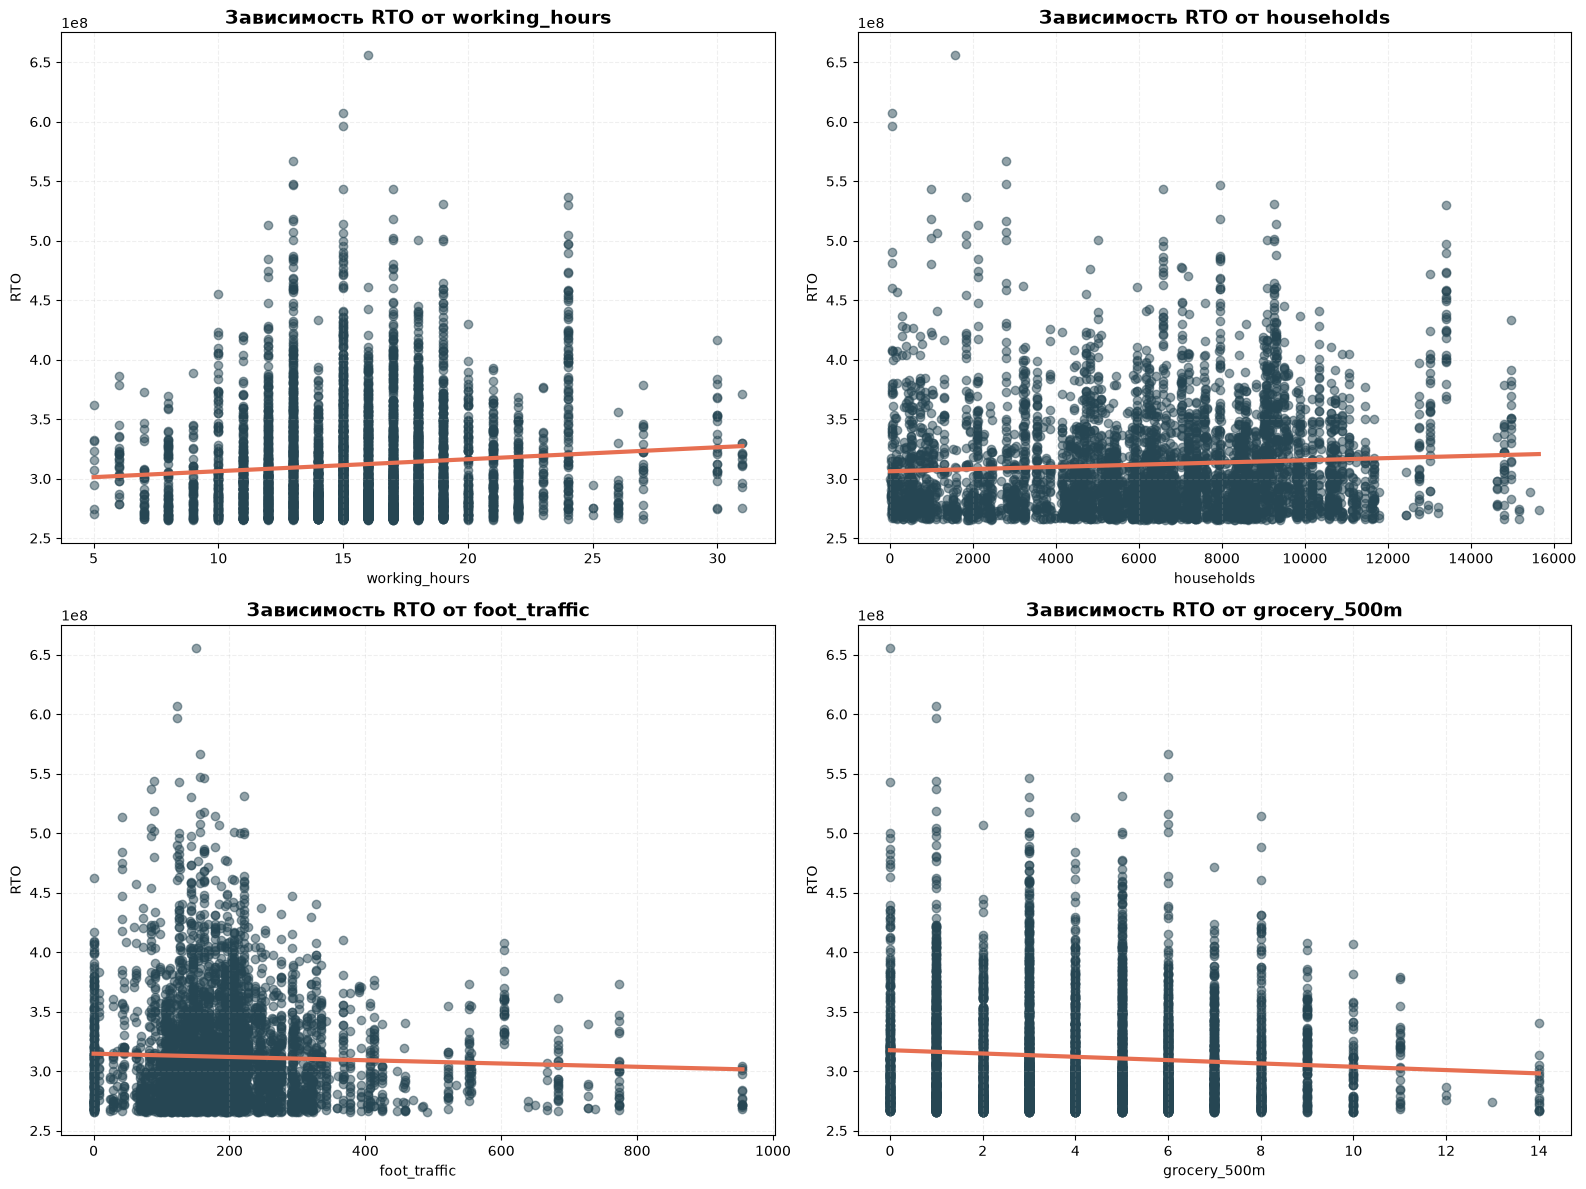

In [62]:
features = ["working_hours", "households", "foot_traffic", "grocery_500m"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(features):
    x = df_high_rto[col]
    y = df_high_rto["rto"]
    axes[i // 2][i % 2].scatter(x, y, alpha=0.5, color=palette[0])
    coef = np.polyfit(x, y, 1)
    f = lambda val: coef[0] * val + coef[1]
    x_val = np.linspace(x.min(), x.max(), 100)
    axes[i // 2][i % 2].plot(x_val, f(x_val), color=palette[4], linewidth=3)
    axes[i // 2][i % 2].set_title(
        f"Зависимость RTO от {col}", weight="bold", fontsize=14
    )
    axes[i // 2][i % 2].set_xlabel(col)
    axes[i // 2][i % 2].set_ylabel("RTO")
    axes[i // 2][i % 2].grid(linestyle="--", alpha=0.2)

plt.tight_layout()

### Временной анализ выручки

Рассмотрим динамику среднего РТО во времени, чтобы выявить сезонность и общие тренды.

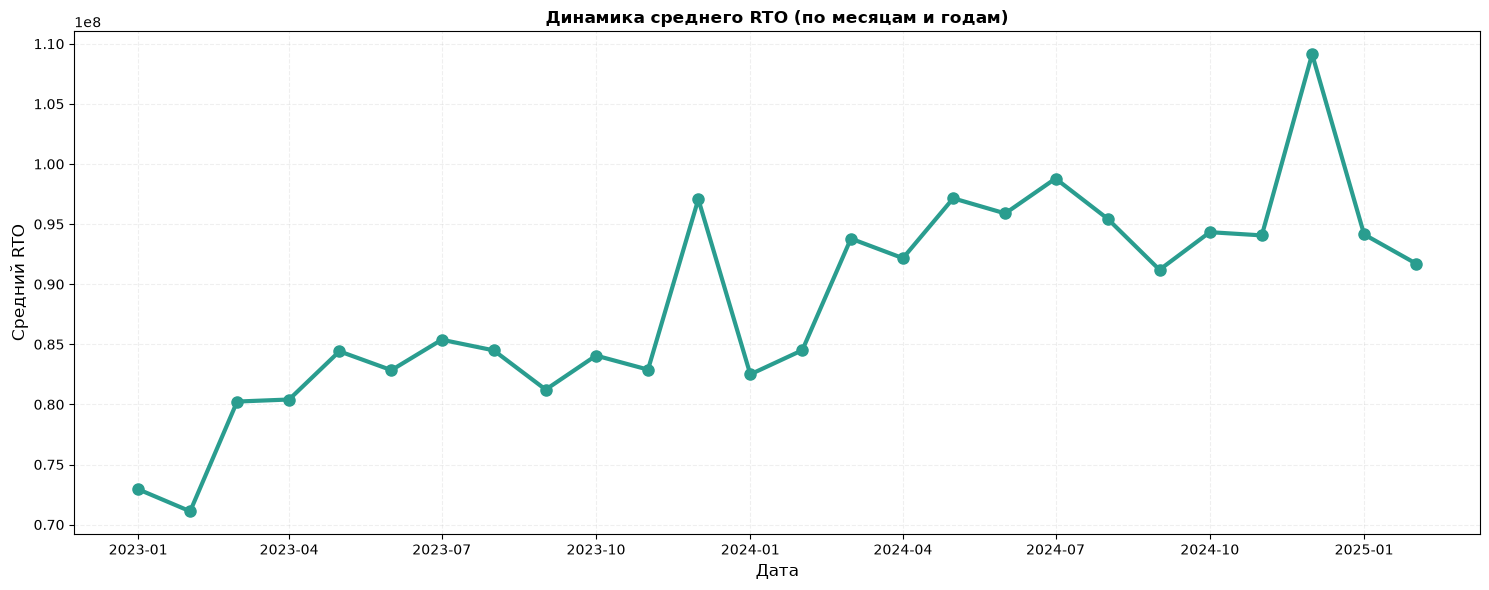

In [63]:
df_groupped = df.groupby(["year", "month"])["rto"].mean().reset_index()
df_groupped["date"] = pd.to_datetime(df_groupped[["year", "month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(
    df_groupped["date"],
    df_groupped["rto"],
    marker="o",
    color=palette[1],
    linewidth=3,
    markersize=8,
)
ax.set_title("Динамика среднего RTO (по месяцам и годам)", weight="bold")
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Средний RTO", fontsize=12)
ax.grid(linestyle="--", alpha=0.2)
plt.tight_layout()

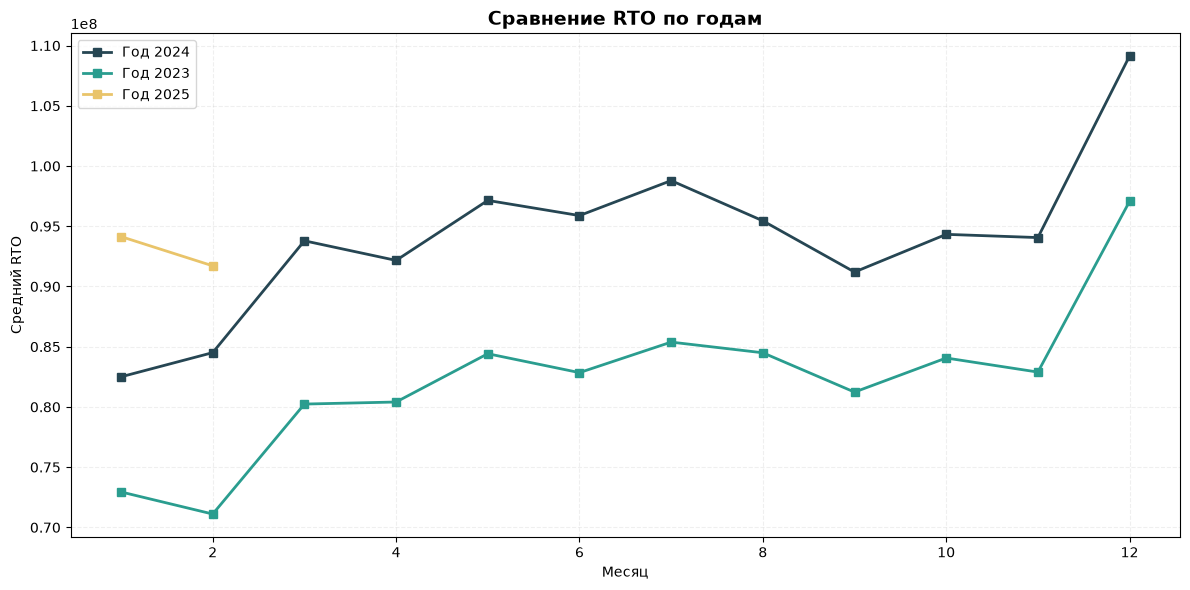

In [64]:
years = df["year"].unique()
fig, ax = plt.subplots(figsize=(12, 6))
for i, year in enumerate(years):
    year_data = df_groupped[df_groupped["year"] == year]
    ax.plot(
        year_data["month"],
        year_data["rto"],
        marker="s",
        label=f"Год {year}",
        color=palette[i],
        linewidth=2,
    )
ax.set_title("Сравнение RTO по годам", weight="bold", fontsize=14)
ax.set_xlabel("Месяц")
ax.set_ylabel("Средний RTO")
ax.grid(linestyle="--", alpha=0.2)
ax.legend()
plt.tight_layout()

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_groupped = df.groupby(["year", "month"])["rto"].mean().reset_index()
df_groupped["date"] = pd.to_datetime(
    df_groupped["year"].astype(str) + "-" + df_groupped["month"].astype(str) + "-01"
)
ts_df = df_groupped.set_index("date")
decomposition = seasonal_decompose(ts_df["rto"], model="additive", period=12)

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10), sharex=True)
components = [
    (decomposition.observed, "Observed", palette[0]),
    (decomposition.trend, "Trend", palette[1]),
    (decomposition.seasonal, "Seasonal", palette[2]),
    (decomposition.resid, "Residual", palette[3]),
]
for i, (data, title, color) in enumerate(components):
    axes[i].plot(data, color=color, linewidth=2)
    axes[i].set_title(title, weight="bold")
    axes[i].grid(True, alpha=0.2)
plt.tight_layout()

ModuleNotFoundError: No module named 'statsmodels'

## Baseline модели

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [67]:
test_interval = df_groupped["date"].tail(2).to_list()
test_interval

[Timestamp('2025-01-01 00:00:00'), Timestamp('2025-02-01 00:00:00')]

Поскольку мы предсказываем будущее (aka значение временного ряда), нельзя делить данные на train и test случайным образом. Т.е. разбиение нужно выполнять последовательно.

In [68]:
test_mask = (df["year"] == 2025) & (df["month"] == 2)
df_train, df_test = df[~test_mask], df[test_mask]
baseline_means = df_train.groupby("store_id")["rto"].mean()
y_pred_baseline = df_test["store_id"].map(baseline_means).fillna(df_train["rto"].mean())
baseline_avg_res = y_pred_baseline.mean()

Оценим ошибку:

In [69]:
y_true = df_test["rto"]
mape_baseline, score_baseline = get_score(y_true, y_pred_baseline)
print(f"MAE: {mean_absolute_error(y_true, y_pred_baseline)}")
print(f"MAPE: {mape_baseline}%")
print(f"Score: {score_baseline}")
print(f"Среднее предсказание: {baseline_avg_res}")

MAE: 9932744.79499896
MAPE: 11.226021597776812%
Score: 78.80819241358391
Среднее предсказание: 88407655.25826178


### Добавление признаков

In [70]:
df = df.sort_values(by=["store_id", "year", "month"]).reset_index(drop=True)
num_lags = 3
for i in range(num_lags):
    df[f"rto_lag{i + 1}"] = df.groupby("store_id")["rto"].shift(i + 1)
df["rto_rolling_mean_3"] = df.groupby("store_id")["rto"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df["rto_rolling_mean_6"] = df.groupby("store_id")["rto"].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
df["rto_rolling_std_3"] = df.groupby("store_id")["rto"].transform(
    lambda x: x.shift(1).rolling(3).std()
)
df["rto_trend"] = df["rto_lag1"] - df["rto_lag2"]
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [71]:
df = df.dropna().reset_index(drop=True)
print(f"Размер датасета после удаления NaN: {df.shape}")

Размер датасета после удаления NaN: (373140, 33)


Пересоздадим переменные, так как были добавлены новые переменные:

In [72]:
test_mask = (df["year"] == 2025) & (df["month"] == 2)

### Ridge регрессия

In [73]:
from sklearn.linear_model import Ridge

In [74]:
X_train = df_train.drop("rto", axis=1)
X_test = df_test.drop("rto", axis=1)
y_train = df_train["rto"]
y_test = df_test["rto"]

In [75]:
categorical_features = df.select_dtypes(include="object").columns.tolist()
numeric_features = (
    df.select_dtypes(exclude="object").drop(columns=["rto"]).columns.tolist()
)
get_stats(df[categorical_features])

,Количество уникальных,Доля,Тип данных
city,3270,0.88,object
region,67,0.02,object
opening_date_cat,3,0.00,object
store_area_cat,4,0.00,object


Выполним кодирование признаков:
1. Числовые признаки обработаем с помощью `standart_scaler`
2. Категориальные кодируем с помощью [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html), чтобы не усложнять Baseline

In [76]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [77]:
df_test = df[test_mask].copy()
df_train = df[~test_mask].copy()

X_train, X_test = df_train.drop("rto", axis=1), df_test.drop("rto", axis=1)
y_train, y_test = df_train["rto"], df_test["rto"]

In [78]:
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)
oe.fit(X_train[categorical_features])

X_train_cat = oe.transform(X_train[categorical_features])
X_test_cat = oe.transform(X_test[categorical_features])

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

In [80]:
X_train = np.hstack([X_train_scaled, X_train_cat])
X_test = np.hstack([X_test_scaled, X_test_cat])

Объединяем:

In [81]:
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
mape_ridge, score_ridge = get_score(y_test, y_pred_ridge)
ridge_avg_res = y_pred_ridge.mean()
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}")
print(f"MAPE: {mape_ridge:.2f}%")
print(f"Score: {score_ridge:.2f}")
print(f"Среднее предсказание: {ridge_avg_res:.2f}")

MAE: 4307229.41
MAPE: 5.37%
Score: 89.55
Среднее предсказание: 90600060.90


### Случайный лес

In [33]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=1000, max_depth=5, random_state=41, n_jobs=-1
)
rf_model.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
mape_rf, score_rf = get_score(y_test, y_pred_rf)
rf_avg_res = y_pred_rf.mean()
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf)}")
print(f"MAPE: {mape_rf}%")
print(f"Score: {score_rf}")
print(f"Среднее предсказание: {ridge_avg_res}")

MAE: 5879675.718533243
MAPE: 7.604007784792123%
Score: 85.37019377432755
Среднее предсказание: 90600060.89718431


### Бустинг

In [ ]:
from xgboost import XGBRegressor

In [ ]:
bst = XGBRegressor(
    n_estimators=1000, max_depth=10, learning_rate=0.1, objective="reg:squarederror"
)
bst.fit(X_train, y_train)
y_pred_bst = bst.predict(X_test)
mape_bst, score_bst = get_score(y_test, y_pred_bst)
bst_avg_res = y_pred_bst.mean()
print(f"MAE: {mean_absolute_error(y_test, y_pred_bst)}")
print(f"MAPE: {mape_bst}%")
print(f"Score: {score_bst}")
print(f"Среднее предсказание: {bst_avg_res}")

MAE: 5503412.957619124
MAPE: 6.664534567314276%
Score: 87.11509107536072
Среднее предсказание: 96187960.0


In [ ]:
bst = XGBRegressor(
    n_estimators=10000,
    max_depth=10,
    learning_rate=0.1,
    objective="reg:squarederror",
    device="cuda",
)
bst.fit(X_train, y_train)
y_pred_bst = bst.predict(X_test)
mape_bst, score_bst = get_score(y_test, y_pred_bst)
bst_avg_res = y_pred_bst.mean()
print(f"MAE: {mean_absolute_error(y_test, y_pred_bst)}")
print(f"MAPE: {mape_bst}%")
print(f"Score: {score_bst}")
print(f"Среднее предсказание: {bst_avg_res}")

c:\Users\Anton\anaconda3\envs\torch311\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:25:44] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


MAE: 5455189.115101034
MAPE: 6.613024160993048%
Score: 87.21127256355268
Среднее предсказание: 96076376.0


### Результат Baseline

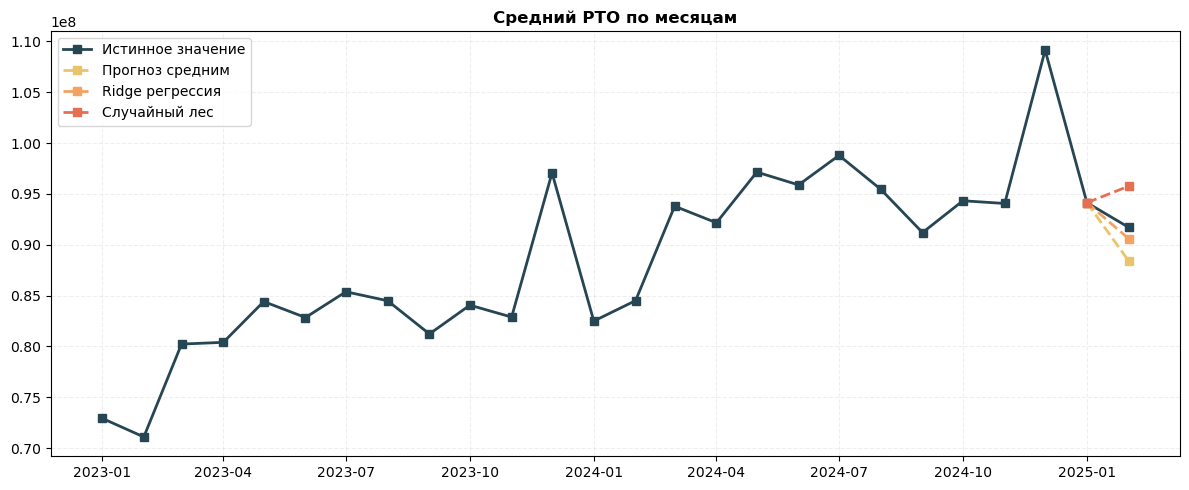

In [84]:
fig, ax = plt.subplots(figsize=(12, 5))

jan_val = df_groupped["rto"].values[-2]
ax.plot(
    df_groupped["date"],
    df_groupped["rto"],
    label="Истинное значение",
    color=palette[0],
    linewidth=2,
    marker="s",
)
ax.plot(
    test_interval,
    [jan_val, baseline_avg_res],
    linewidth=2,
    color=palette[2],
    linestyle="--",
    marker="s",
    label="Прогноз средним",
)
ax.plot(
    test_interval,
    [jan_val, ridge_avg_res],
    linewidth=2,
    color=palette[3],
    linestyle="--",
    marker="s",
    label="Ridge регрессия",
)
ax.plot(
    test_interval,
    [jan_val, rf_avg_res],
    linewidth=2,
    color=palette[4],
    linestyle="--",
    marker="s",
    label="Случайный лес",
)
ax.legend()
ax.grid(linestyle="--", alpha=0.2)
ax.set_title("Средний РТО по месяцам", weight="bold")
plt.tight_layout()

## Применение нейросети


In [85]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# mac only
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: mps


In [86]:
from sklearn.preprocessing import StandardScaler

valid_months_mask = ((df_train["year"] == 2024) & (df_train["month"] == 12)) | (
    (df_train["year"] == 2025) & (df_train["month"] == 1)
)

df_valid_nn = df_train[valid_months_mask].copy()
df_train_nn = df_train[~valid_months_mask].copy()


def get_raw_features(df_subset):
    X_num = df_subset[numeric_features].values
    X_cat = oe.transform(df_subset[categorical_features])
    return np.hstack([X_num, X_cat])


X_train_raw = get_raw_features(df_train_nn)
X_valid_raw = get_raw_features(df_valid_nn)
X_test_raw = get_raw_features(df_test)

nn_scaler = StandardScaler()
X_train_nn = nn_scaler.fit_transform(X_train_raw).astype("float32")
X_valid_nn = nn_scaler.transform(X_valid_raw).astype("float32")
X_test_nn = nn_scaler.transform(X_test_raw).astype("float32")

y_train_orig = df_train_nn["rto"].values.astype("float32")
y_valid_orig = df_valid_nn["rto"].values.astype("float32")
y_test_orig = df_test["rto"].values.astype("float32")

y_train_log = np.log1p(y_train_orig)
target_mean, target_std = y_train_log.mean(), y_train_log.std()

y_train_scaled = (y_train_log - target_mean) / target_std
y_valid_scaled = (np.log1p(y_valid_orig) - target_mean) / target_std
y_test_scaled = (np.log1p(y_test_orig) - target_mean) / target_std

print(f"Форма входных признаков: {X_train_nn.shape}")

Форма входных признаков: (317169, 32)


In [87]:
train_dataset = TensorDataset(
    torch.tensor(y_train_scaled, dtype=torch.float32),
    torch.tensor(X_train_nn, dtype=torch.float32),
)
valid_dataset = TensorDataset(
    torch.tensor(y_valid_scaled, dtype=torch.float32),
    torch.tensor(X_valid_nn, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(y_test_scaled, dtype=torch.float32),
    torch.tensor(X_test_nn, dtype=torch.float32),
)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Модель полносвязной нейросети (MLP)


In [88]:
class RTOFullyConnectedModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, features):
        output = self.fc1(features)
        output = torch.relu(output)
        output = self.dropout(output)

        output = self.fc2(output)
        output = torch.relu(output)
        output = self.dropout(output)

        output = self.fc3(output)
        return output.squeeze(1)

In [89]:
def inverse_target(y_scaled):
    y_log = y_scaled * target_std + target_mean
    y_rto = np.expm1(y_log)
    return y_rto

In [90]:
input_dim = X_train_nn.shape[1]

model = RTOFullyConnectedModel(input_dim=input_dim, hidden_dim=256, dropout=0.1).to(
    device
)

EPOCHS = 12
LR = 0.05

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)

In [91]:
def train(model_net, dataloader, optimizer_net, criterion_net):
    model_net.train()
    total_loss = 0
    total_count = 0

    for target, features in dataloader:
        target = target.to(device)
        features = features.to(device)
        optimizer_net.zero_grad()
        predicted = model_net(features)
        loss = criterion_net(predicted, target)
        loss.backward()
        optimizer_net.step()

        total_loss += loss.item() * len(target)
        total_count += len(target)

    return total_loss / total_count


def evaluate(model_net, dataloader, criterion_net, y_true_orig):
    model_net.eval()
    total_loss = 0
    total_count = 0
    predictions = []

    with torch.no_grad():
        for target, features in dataloader:
            target = target.to(device)
            features = features.to(device)
            predicted = model_net(features)
            loss = criterion_net(predicted, target)
            total_loss += loss.item() * len(target)
            total_count += len(target)
            predictions.append(predicted.cpu().numpy())
    preds_scaled = np.concatenate(predictions)
    preds_rto = inverse_target(preds_scaled)
    mape_val, score_val = get_score(y_true_orig, preds_rto)
    return {
        "loss": total_loss / total_count if total_count > 0 else 0,
        "mape": mape_val,
        "score": score_val,
        "preds": preds_rto,
    }

Запускаем обучение:


In [92]:
valid_mape_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train(model, train_loader, optimizer, criterion)
    valid_result = evaluate(model, valid_loader, criterion, y_valid_orig)

    valid_mape_history.append(valid_result["mape"])
    scheduler.step()

    print(
        f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Valid MAPE: {valid_result['mape']:.2f}%, Score: {valid_result['score']:.2f}"
    )

Epoch 1: Train Loss: 0.0648, Valid MAPE: 7.64%, Score: 85.31
Epoch 2: Train Loss: 0.0467, Valid MAPE: 7.83%, Score: 84.95
Epoch 3: Train Loss: 0.0433, Valid MAPE: 7.13%, Score: 86.25
Epoch 4: Train Loss: 0.0415, Valid MAPE: 7.68%, Score: 85.23
Epoch 5: Train Loss: 0.0402, Valid MAPE: 7.32%, Score: 85.90
Epoch 6: Train Loss: 0.0395, Valid MAPE: 7.04%, Score: 86.41
Epoch 7: Train Loss: 0.0387, Valid MAPE: 7.21%, Score: 86.09
Epoch 8: Train Loss: 0.0382, Valid MAPE: 7.12%, Score: 86.28
Epoch 9: Train Loss: 0.0377, Valid MAPE: 7.00%, Score: 86.49
Epoch 10: Train Loss: 0.0374, Valid MAPE: 7.02%, Score: 86.46
Epoch 11: Train Loss: 0.0370, Valid MAPE: 7.12%, Score: 86.27
Epoch 12: Train Loss: 0.0369, Valid MAPE: 7.08%, Score: 86.34


Проверяем результат на тесте (февраль 2025):


In [94]:
test_result = evaluate(model, test_loader, criterion, y_test_orig)
print(
    f"Test MAPE на феврале 2025 (Базовая MLP): {test_result['mape']:.2f}%, Score: {test_result['score']:.2f}"
)

Test MAPE на феврале 2025 (Базовая MLP): 5.32%, Score: 89.65


## Сравнительный анализ конфигураций нейросети


In [ ]:
class ModelWithBatchNorm(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, features):
        return self.net(features).squeeze(1)


class DeeperModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1),
        )

    def forward(self, features):
        return self.net(features).squeeze(1)

Обучим Model 2, Model 3 для сравнения их метрик:


In [97]:
def train_and_eval_model(model_net, name, optimizer_cls=torch.optim.Adam, lr=0.001):
    print(f"\n--- Обучение модели: {name} ---")

    criterion_net = nn.MSELoss()
    optimizer_net = optimizer_cls(model_net.parameters(), lr=lr)

    scheduler_net = torch.optim.lr_scheduler.StepLR(
        optimizer_net, step_size=3, gamma=0.8
    )

    epochs = 12
    for epoch in range(1, epochs + 1):
        train_loss = train(model_net, train_loader, optimizer_net, criterion_net)
        valid_result = evaluate(model_net, valid_loader, criterion_net, y_valid_orig)
        scheduler_net.step()
        print(
            f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Valid MAPE: {valid_result['mape']:.2f}%"
        )

    test_result = evaluate(model_net, test_loader, criterion_net, y_test_orig)
    print(
        f"ИТОГ {name} на тесте: MAPE = {test_result['mape']:.2f}%, Score = {test_result['score']:.2f}"
    )
    return test_result


model2 = ModelWithBatchNorm(input_dim).to(device)
res_m2 = train_and_eval_model(model2, "Model 2 (BatchNorm + Adam)", lr=0.005)

model3 = DeeperModel(input_dim).to(device)
res_m3 = train_and_eval_model(model3, "Model 3 (Deep + BatchNorm + Adam)", lr=0.005)


--- Обучение модели: Model 2 (BatchNorm + Adam) ---
Epoch 1: Train Loss: 0.0518, Valid MAPE: 8.01%
Epoch 2: Train Loss: 0.0415, Valid MAPE: 9.08%
Epoch 3: Train Loss: 0.0377, Valid MAPE: 4.94%
Epoch 4: Train Loss: 0.0355, Valid MAPE: 6.50%
Epoch 5: Train Loss: 0.0345, Valid MAPE: 6.17%
Epoch 6: Train Loss: 0.0342, Valid MAPE: 4.72%
Epoch 7: Train Loss: 0.0328, Valid MAPE: 5.40%
Epoch 8: Train Loss: 0.0327, Valid MAPE: 5.03%
Epoch 9: Train Loss: 0.0321, Valid MAPE: 4.64%
Epoch 10: Train Loss: 0.0314, Valid MAPE: 4.87%
Epoch 11: Train Loss: 0.0311, Valid MAPE: 5.06%
Epoch 12: Train Loss: 0.0310, Valid MAPE: 4.75%
ИТОГ Model 2 (BatchNorm + Adam) на тесте: MAPE = 4.96%, Score = 90.33

--- Обучение модели: Model 3 (Deep + BatchNorm + Adam) ---
Epoch 1: Train Loss: 0.0586, Valid MAPE: 9.39%
Epoch 2: Train Loss: 0.0457, Valid MAPE: 5.38%
Epoch 3: Train Loss: 0.0433, Valid MAPE: 5.18%
Epoch 4: Train Loss: 0.0398, Valid MAPE: 6.94%
Epoch 5: Train Loss: 0.0391, Valid MAPE: 6.21%
Epoch 6: Train 